In [1]:
%pip install "dask[dataframe]" pyarrow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import dask.dataframe as dd

In [19]:

INPUT_CSV_PATH = './data/yellow_tripdata_2016-01.csv' # This one is from the Kaggle data set
df_csv = dd.read_csv(INPUT_CSV_PATH,  assume_missing=True) # assume_missing to avoid Dask integer assumption error
print("Loaded kaggle.csv as Dask DataFrame")

Loaded kaggle.csv as Dask DataFrame


In [20]:
print(f"kaggle.csv: {df_csv.npartitions} partitions, {len(df_csv.columns)} columns")

kaggle.csv: 26 partitions, 19 columns


In [21]:
df_csv_d = df_csv.drop_duplicates()
print("Deduplication registered.")

Deduplication registered.


In [22]:
print(f"df_csv_d partitions: {df_csv_d.npartitions}")

df_csv_d partitions: 26


In [23]:

INPUT_PARQUET_PATH = './data/yellow_tripdata_2016-01.parquet' # This one is from NYC/TLC
df_parquet = dd.read_parquet(INPUT_PARQUET_PATH)
print("Loaded nyc.parquet as Dask DataFrame")

Loaded nyc.parquet as Dask DataFrame


In [24]:
print(f"nyc.parquet: {df_parquet.npartitions} partitions, {len(df_parquet.columns)} columns")

nyc.parquet: 1 partitions, 19 columns


In [25]:
df_parquet_d = df_parquet.drop_duplicates()
print("Deduplication registered.")

Deduplication registered.


In [26]:
print(f"colnames: {df_csv_d.columns.tolist()}")

colnames: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag', 'dropoff_longitude', 'dropoff_latitude', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount']


In [27]:
print(f"colnames: {df_parquet_d.columns.tolist()}")

colnames: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


In [28]:
df_csv_d_d = df_csv_d.drop(columns=["VendorID", "RatecodeID","store_and_fwd_flag", "payment_type","fare_amount", "extra",
       "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge"])
print(f"colnames: {df_csv_d_d.columns}")

colnames: Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'total_amount'],
      dtype='object')


In [29]:
df_parquet_d_d = df_parquet_d.drop(columns=["VendorID", "RatecodeID","store_and_fwd_flag", "payment_type","fare_amount", "extra",
       "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge", "congestion_surcharge", "airport_fee","passenger_count"])
print(f"colnames: {df_parquet_d_d.columns}")
print(df_parquet_d_d.shape)

colnames: Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance',
       'PULocationID', 'DOLocationID', 'total_amount'],
      dtype='object')
(<dask_expr.expr.Scalar: expr=(Drop(frame=DropDuplicates(frame=ReadParquetFSSpec(705b4ee)), columns=['VendorID', 'RatecodeID', 'store_and_fwd_flag', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee', 'passenger_count'])).size() // 6, dtype=int32>, 6)


In [30]:
print(f"df_parquet_d_d partitions: {df_parquet_d_d.npartitions}")

df_parquet_d_d partitions: 1


In [31]:
print(f"df_csv_d_d partitions: {df_csv_d_d.npartitions}")

df_csv_d_d partitions: 26


In [32]:
composite_keys = [ "tpep_pickup_datetime", 
    "tpep_dropoff_datetime",  "total_amount" ,"trip_distance" ]

In [33]:
df_csv_d_d.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,total_amount
25,2016-01-01 00:00:09,2016-01-01 00:07:18,2.0,1.20,-73.963913,40.712173,-73.951332,40.712200,8.30
26,2016-01-01 00:00:10,2016-01-01 00:06:15,2.0,0.97,-73.999397,40.743900,-73.988876,40.745319,7.30
53,2016-01-01 00:00:30,2016-01-01 00:03:06,1.0,0.35,-73.992348,40.743439,-73.996422,40.746063,6.89
63,2016-01-01 00:00:39,2016-01-01 00:08:41,1.0,2.20,-73.969872,40.768509,-73.949348,40.787766,10.30
92,2016-01-01 00:01:07,2016-01-01 00:05:04,2.0,0.94,-73.991974,40.726479,-74.003082,40.722050,6.30


In [34]:
# Dask doesn't have .info(); dtypes are available without computing
print(df_csv_d_d.dtypes)

tpep_pickup_datetime     string[pyarrow]
tpep_dropoff_datetime    string[pyarrow]
passenger_count                  float64
trip_distance                    float64
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
total_amount                     float64
dtype: object


In [35]:
print(df_parquet_d_d.dtypes)

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
trip_distance                   float64
PULocationID                      int64
DOLocationID                      int64
total_amount                    float64
dtype: object


In [36]:
df_parquet_d_d.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,PULocationID,DOLocationID,total_amount
0,2016-01-01 00:12:22,2016-01-01 00:29:14,3.2,48,262,18.36
1,2016-01-01 00:41:31,2016-01-01 00:55:10,1.0,162,48,10.80
2,2016-01-01 00:53:37,2016-01-01 00:59:57,0.9,246,90,7.30
3,2016-01-01 00:13:28,2016-01-01 00:18:07,0.8,170,162,6.30
4,2016-01-01 00:33:04,2016-01-01 00:47:14,1.8,161,140,12.30


In [37]:
df_csv_d_d['tpep_pickup_datetime'] = dd.to_datetime(df_csv_d_d['tpep_pickup_datetime'])

In [38]:
df_csv_d_d['tpep_dropoff_datetime'] = dd.to_datetime(df_csv_d_d['tpep_dropoff_datetime'])

In [39]:
print(df_parquet_d_d.dtypes)

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
trip_distance                   float64
PULocationID                      int64
DOLocationID                      int64
total_amount                    float64
dtype: object


In [45]:

# Forcing both datetime variables to be the same type
# (because otherwise on is [us] the other is [ns], throwing error during merge)
df_csv_d_d["tpep_pickup_datetime"] = df_csv_d_d["tpep_pickup_datetime"].astype("datetime64[ns]")
df_csv_d_d["tpep_dropoff_datetime"] = df_csv_d_d["tpep_dropoff_datetime"].astype("datetime64[ns]")

df_parquet_d_d["tpep_pickup_datetime"] = df_parquet_d_d["tpep_pickup_datetime"].astype("datetime64[ns]")
df_parquet_d_d["tpep_dropoff_datetime"] = df_parquet_d_d["tpep_dropoff_datetime"].astype("datetime64[ns]")

In [46]:
print("Performing left join on composite keys...")
df_combined = dd.merge(df_csv_d_d, df_parquet_d_d, on=composite_keys, how='left')
print("Merge graph built (lazy)")

Performing left join on composite keys...
Merge graph built (lazy)


In [47]:
print(f"df_combined partitions: {df_combined.npartitions}")
print(f"Columns: {df_combined.columns.tolist()}")

df_combined partitions: 26
Columns: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'total_amount', 'PULocationID', 'DOLocationID']


Computing class distribution...
Computing dropoff location distribution...


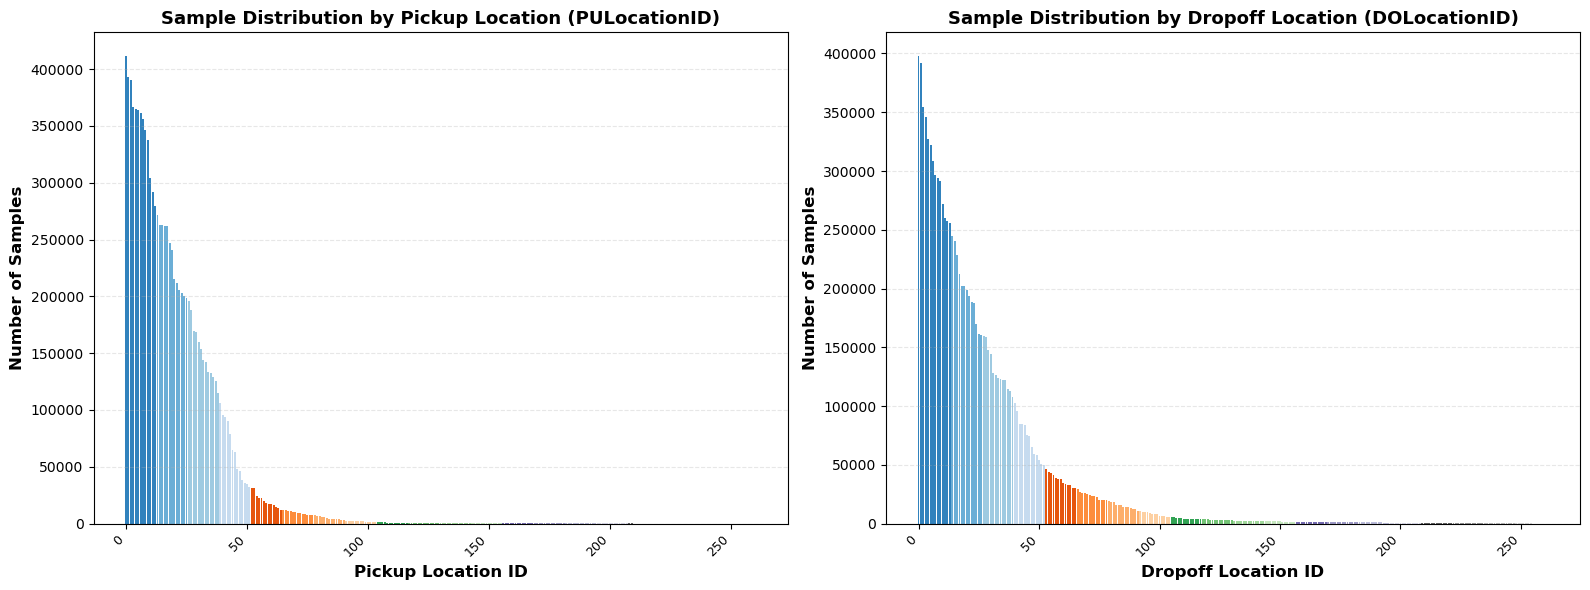


Class Distribution Summary:
  Total unique pickup locations: 261
  Total unique dropoff locations: 262

Top 5 Pickup Locations:
PULocationID
237.0    411861
161.0    393003
236.0    390752
230.0    366646
234.0    365257
Name: count, dtype: int64

Top 5 Dropoff Locations:
DOLocationID
161.0    398100
236.0    392143
237.0    354793
170.0    346264
230.0    326983
Name: count, dtype: int64


In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Plot class distribution by Location IDs
print("Computing class distribution...")
pu_counts = df_combined['PULocationID'].value_counts().compute().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart for PULocationID
colors1 = plt.cm.tab20c(np.linspace(0, 1, len(pu_counts)))
ax1.bar(range(len(pu_counts)), pu_counts.values, color=colors1)
ax1.set_xlabel('Pickup Location ID', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax1.set_title('Sample Distribution by Pickup Location (PULocationID)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

# Bar chart for DOLocationID
print("Computing dropoff location distribution...")
do_counts = df_combined['DOLocationID'].value_counts().compute().sort_values(ascending=False)
colors2 = plt.cm.tab20c(np.linspace(0, 1, len(do_counts)))
ax2.bar(range(len(do_counts)), do_counts.values, color=colors2)
ax2.set_xlabel('Dropoff Location ID', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax2.set_title('Sample Distribution by Dropoff Location (DOLocationID)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nClass Distribution Summary:")
print(f"  Total unique pickup locations: {len(pu_counts)}")
print(f"  Total unique dropoff locations: {len(do_counts)}")
print(f"\nTop 5 Pickup Locations:\n{pu_counts.head()}")
print(f"\nTop 5 Dropoff Locations:\n{do_counts.head()}")

In [49]:
print("Exporting to Parquet directory...")
RESULT_PARQUET_PATH = './data/combined_parquet/'
df_combined.to_parquet(RESULT_PARQUET_PATH, write_index=False)
print(f"Done! Saved under {RESULT_PARQUET_PATH} directory")


Exporting to Parquet directory...
Done! Saved under ./data/combined_parquet/ directory


In [50]:

print("Exporting to single CSV...")
RESULT_CSV_PATH = './data/combined.csv'
df_combined.to_csv(RESULT_CSV_PATH, single_file=True, index=False)
print(f"Done. Saved as {RESULT_CSV_PATH}")

Exporting to single CSV...
Done. Saved as ./data/combined.csv
